In [29]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la

In [55]:

# nominal CoSMO type with medium penalty
n_strains = 2
n_resources = 5

c = np.zeros((n_strains,n_resources))
c[0,0] = 1 #both uptake glucose
c[1,0] = 1
c[0,1] = 1 #crossfeeding
c[1,2] = 1
c[1,3] = 1 #strain 2 uptakes the intermediate

l = np.zeros((n_strains,n_resources))
l[0,0] = 1
l[1,0] = 1
l[1,3] = 1

#nutrient "quality"
w = np.ones(n_resources)

#chemostat feeding
k = np.zeros(n_resources)
k[0] = 1

#chemostat dilution rate
r = np.ones(n_resources)*0.2
#r = np.array([1,0.2,0.2])

#death rate
m = np.ones(n_strains)*0.3

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[0,2,0] = 0.5 #even split, this is the sum of phis, should limit community growth
CF_array[0,3,0] = 0.5
CF_array[1,1,0] = 1
CF_array[1,4,3] = 0.4 #lets give it a non-unitary efficency

print(c)

print(CF_array)

ratios = np.array([0.49,0.51])

D = np.array([0.01,0.01]) #diffusion constant for cells

H = np.array([100,1,1,10,10]) #diffusion constants for resources


[[1. 1. 0. 0. 0.]
 [1. 0. 1. 1. 0.]]
[[[0.  0.  0.  0.  0. ]
  [0.  0.  0.  0.  0. ]
  [0.5 0.  0.  0.  0. ]
  [0.5 0.  0.  0.  0. ]
  [0.  0.  0.  0.  0. ]]

 [[0.  0.  0.  0.  0. ]
  [1.  0.  0.  0.  0. ]
  [0.  0.  0.  0.  0. ]
  [0.  0.  0.  0.  0. ]
  [0.  0.  0.  0.4 0. ]]]


In [56]:
def get_steady_state(n_strains,n_resources,ratios,c,l,w,k,r,m,tau,H,CF_array,N_0,R_0,dt,t_final):
    
    steady_state = False
    
    attempts = 0
    
    while not steady_state:
        
        if attempts > 0:
            
            t_final = t_final*2
            print('No steady state found on attempt %s'%attempts, ' running for longer')
            
            
        epsilon = 1e-4
        t_min = 30
        
        
        nsteps = int(t_final/dt)

        time = np.zeros(nsteps+1)

        N = np.zeros((n_strains,nsteps+1))
        N[:,0] = N_0*ratios

        R = np.zeros((n_resources,nsteps+1)) + R_0
        #R[0,0] = R_0

        for tt in range(nsteps):


            #I am too lazy to figure out matricies, although I'm sure that's easy
            dN = np.zeros(n_strains)
            for ii in range(n_strains):
                dN[ii] = -1/tau*N[ii,tt]*m[ii]
                for aa in range(n_resources):
                    dN[ii] += 1/tau*N[ii,tt]*(1-l[ii,aa])*w[aa]*c[ii,aa]*R[aa,tt]

            dR = np.zeros(n_resources)
            for aa in range(n_resources):
                dR[aa] = k[aa] - r[aa]*R[aa,tt]

                for ii in range(n_strains):
                    dR[aa] += -N[ii,tt]*c[ii,aa]*R[aa,tt]

                    for bb in range(n_resources):
                        dR[aa] += N[ii,tt]*CF_array[ii,aa,bb]*l[ii,bb]*w[bb]/w[aa]*c[ii,bb]*R[bb,tt]


            N[:,tt+1] = N[:,tt] + dN*dt
            R[:,tt+1] = R[:,tt] + dR*dt
            time[tt+1] = time[tt]+dt


            if time[tt+1] > t_min and np.sum(dN) < epsilon and not steady_state:
                steady_state = True
                Nss = N[:,tt+1]
                Rss = R[:,tt+1]
                Tss = time[tt+1]
                #break
        
        attempts += 1
        
        if attempts > 5:
            break
    
    return N[:,:tt+1],R[:,:tt+1],time[:tt+1],Nss,Rss,Tss

In [57]:
#troubleshooting for the steady state function

N_0 = 2
R_0 = 1
dt = 0.001
t_final = 50

N,R,time,Nss,Rss,Tss = get_steady_state(n_strains,n_resources,ratios,c,l,w,k,r,m,tau,H,CF_array,N_0,R_0,dt,t_final)

print(Nss,Rss)

[1.00803135 0.68668314] [0.52778864 0.3000156  0.30001604 0.30001604 0.41412812]


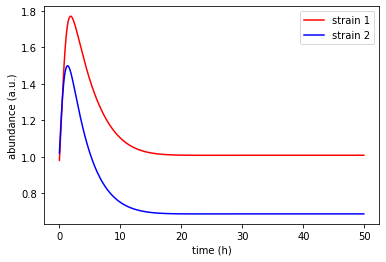

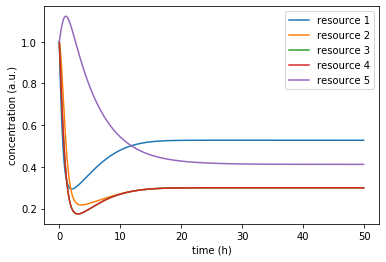

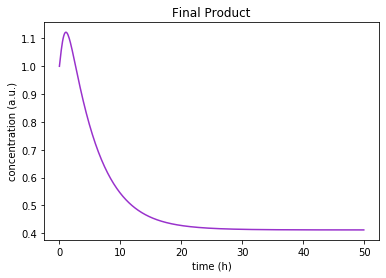

In [58]:
stride = 100
for nn in range(n_strains):
    if nn==0:
        col = 'r'
    elif nn==1:
        col = 'b'
    else:
        col = 'k'
    plt.plot(time[::stride],N[nn,::stride],label='strain %s'%int(nn+1),c = col)
    #plt.axhline(y=Nss[nn])
plt.legend()
#plt.axvline(x=Tss)
plt.xlabel('time (h)')
plt.ylabel('abundance (a.u.)')
plt.show()

for rr in range(n_resources):
    plt.plot(time[::stride],R[rr,::stride],label='resource %s'%int(rr+1))
plt.legend()
plt.xlabel('time (h)')
plt.ylabel('concentration (a.u.)')
plt.show()

plt.plot(time[::stride],R[-1,::stride],c = 'darkorchid')
plt.title('Final Product')
plt.xlabel('time (h)')
plt.ylabel('concentration (a.u.)')
plt.show()


In [59]:
def get_A_F(n_strains, n_resources, tau,l,w,c,CF_array):
    
    # make A
    A = np.zeros((n_resources,n_strains))
    for aa in range(n_resources):
        for ii in range(n_strains):
            A[aa,ii] = tau*(1-l[ii,aa])*w[aa]*c[ii,aa]
            
    #make F
    F = np.zeros((n_strains,n_resources,n_resources))
    for ii in range(n_strains):
        for aa in range(n_resources):
            for bb in range(n_resources):
                F[ii,aa,bb] = CF_array[ii,aa,bb]*l[ii,bb]*w[bb]/w[aa]*c[ii,bb]
                
    return A,F

In [60]:
def calc_T(n_strains,n_resources,Nss,Rss,A,B,D,q):
    
    T = np.zeros((n_strains,n_strains))
    
    for ii in range(n_strains):
        #this matrix is diagonal, so we only need to loop through once
        T[ii,ii] = -D[ii]*q**2 - B[ii]
        
        for bb in range(n_resources):
             T[ii,ii] += Rss[bb]*A[bb,ii]
    
    return T

def calc_U(n_strains,n_resources,Nss,A):
    
    U = np.zeros((n_strains,n_resources))
    for ii in range(n_strains):
        for aa in range(n_resources):
            U[ii,aa] = A[aa,ii]*Nss[ii]
            
    return U

def calc_W(n_strains,n_resources,Nss,F,H,r,c,q):
    
    W = np.zeros((n_resources,n_resources))
    for aa in range(n_resources):
        for bb in range(n_resources):
            if aa==bb:
                #print('H = ',np.size(H))
                #print('r = ',np.size(r))
                W[aa,bb] = -(q**2*H[aa] + r[aa])
            else:
                W[aa,bb]
        
            for jj in range(n_strains):

                W[aa,bb] += Nss[jj]*F[jj,aa,bb]
                
                if aa==bb:
                    
                    W[aa,bb] += -Nss[jj]*c[jj,aa]
    
    return W

def calc_V(n_strains,n_resources,Rss,F,c):
    
    V = np.zeros((n_resources,n_strains))
    for aa in range(n_resources):
        for ii in range(n_strains):
            V[aa,ii] = -c[ii,aa]*Rss[aa]
            
            for bb in range(n_resources):
                V[aa,ii] += F[ii,aa,bb]*Rss[bb]
    return V

def build_big_matrix(n_strains,n_resources,Nss,Rss,U,V,A,B,D,F,H,r,c,q):
    
    M = np.zeros((int(n_strains+n_resources),int(n_strains+n_resources)))
    
    T = calc_T(n_strains,n_resources,Nss,Rss,A,B,D,q)
    W = calc_W(n_strains,n_resources,Nss,F,H,r,c,q)
    
    M[0:n_strains,0:n_strains] = T
    M[0:n_strains,n_strains:] = U
    M[n_strains:,0:n_strains] = V
    M[n_strains:,n_strains:] = W
    
    return M

"""
#lets actually calculate some stuff!
#first, the steady state for our parameter set
N_0 = 0.02
R_0 = 1
dt = 0.01
t_final = 1000
Nss,Rss,Tss = get_steady_state(n_strains,n_resources,c,l,w,k,r,m,tau,D,H,CF_array,N_0,R_0,dt,t_final)
"""



'\n#lets actually calculate some stuff!\n#first, the steady state for our parameter set\nN_0 = 0.02\nR_0 = 1\ndt = 0.01\nt_final = 1000\nNss,Rss,Tss = get_steady_state(n_strains,n_resources,c,l,w,k,r,m,tau,D,H,CF_array,N_0,R_0,dt,t_final)\n'

In [61]:
# as U and V do not depend on q, we will pre-compute them for every steady state

A,F = get_A_F(n_strains, n_resources, tau,l,w,c,CF_array)

U = calc_U(n_strains,n_resources,Nss,A)
V = calc_V(n_strains,n_resources,Rss,F,c)

#now its time to calculate some lambdas as a function of q
npts = 10000
qs = np.linspace(0,100,npts)

#qs = 1/lengths

lambdas = np.zeros((int(n_strains+n_resources),npts))
vvvec = []

for nn in range(npts):
    
    q = qs[nn]
    
    M = build_big_matrix(n_strains,n_resources,Nss,Rss,U,V,A,B,D,F,H,r,c,q)
    
    vals,vecs = la.eig(M)
    
    lambdas[:,nn] = vals
    vvvec.append(vecs)



/Users/stevenredford/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:25: ComplexWarning: Casting complex values to real discards the imaginary part


unstable modes!
maximum eigenvalue = 0.029466875716058712
maximum eigenvector =  [ 0.00000000e+00+0.j  0.00000000e+00+0.j -6.55373724e-04+0.j
  5.29120051e-01+0.j  8.18815963e-01+0.j  6.18677565e-01+0.j
  6.18677565e-01-0.j]


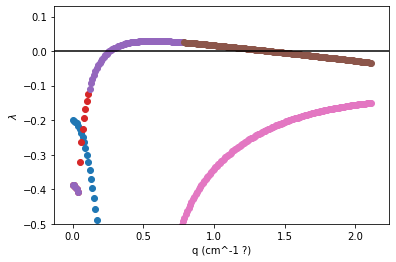

In [62]:
if (lambdas>0).any():
    print('unstable modes!')
    whr = np.where(lambdas>0)
    #print('unstable between %s and'%(1/qs[whr[1][-1]]),'%s'%(1/qs[whr[1][0]]))
    print('maximum eigenvalue = %s'%(np.amax(lambdas)))
    
    indx = np.where(lambdas == np.amax(lambdas))
    max_x = int(indx[1][0])
    print('maximum eigenvector = ',vvvec[max_x][0][:])
    
    av = np.mean(qs[whr[1][:]])
    sprd = np.amax(whr[1]) - np.amin(whr[1])
    
    
    add = 100
    rng = int(sprd+add)
    
    overshoot = np.amin(whr[1][0])-add/2
    
    if overshoot<0:
        strt = 0
        stp = int(np.amax(whr[1][:]) + add/2 - overshoot)
    
    else:
        
        strt = int(overshoot)
        stp = int(np.amax(whr[1][:]) + add/2)
    
    mx = np.amax(lambdas)+0.1
    mn = -0.5
    
    #strt = 0
    #stp = -1
    
    #plot the result!
    fig, ax = plt.subplots()
    #ax.set_xscale('log')
    #ax.set_xlim(0,10)
    for ii in range(int(n_strains+n_resources)):
        
        indx = int(strt+ii)
        
        ax.scatter(qs[strt:stp],lambdas[ii,strt:stp])
    plt.xlabel('q (cm^-1 ?)')
    plt.ylabel('$\lambda$')
    plt.ylim(mn,mx)
    plt.axhline(y=0,c='k')
    #plt.xlim(strt,stp)
    plt.show()

else:
    
    #plot the result!
    fig, ax = plt.subplots()
    #ax.set_xscale('log')
    #ax.set_xlim(0,10)
    for ii in range(int(n_strains+n_resources)):
        ax.scatter(qs,lambdas[ii,:])
    plt.xlabel('q (cm^-1)')
    plt.ylabel('$\lambda$')
    #plt.ylim(-1,1)
    #plt.xlim(-0.01,0.5)
    plt.show()